<a href="https://colab.research.google.com/github/machiwao/CCDEPLRL_EXERCISES_COM222/blob/main/Exercise7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 7

Text Generation using LSTM

In [123]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku
import tensorflow as tf
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [124]:
tokenizer = Tokenizer()

!wget --no-check-certificate \
    https://raw.githubusercontent.com/cibernox/storyteller/refs/heads/master/snow-white.txt \
    -O /tmp/snowwhite.txt

data = open('/tmp/snowwhite.txt').read()

--2025-05-27 09:17:35--  https://raw.githubusercontent.com/cibernox/storyteller/refs/heads/master/snow-white.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1520 (1.5K) [text/plain]
Saving to: ‘/tmp/snowwhite.txt’

/tmp/snowwhite.txt  100%[===================>]   1.48K  --.-KB/s    in 0s      

2025-05-27 09:17:35 (29.5 MB/s) - ‘/tmp/snowwhite.txt’ saved [1520/1520]



In [127]:
data

'Once upon a time ... in a great castle,\na Prince\'s daughter grew up happy and contented,\nin spite of a jealous stepmother.\nShe was very pretty, with blue eyes and long\nblack hair. Her skin was delicate and fair,\nand so she was called Snow White. Everyone was\nquite sure she would become very beautiful.\nThough her stepmother was a wicked woman,\nshe too was very beautiful, and the magic mirror\ntold her this every day, whenever she asked it.\n\n"Mirror, mirror on the wall, who is the\nloveliest lady in the land?"\n\nThe reply was always; "You are, your Majesty,"\nuntil the dreadful day when she heard it say,\n"Snow White is the loveliest in the land."\n\nThe stepmother was furious and, wild with jealousy,\nbegan plotting to get rid of her rival. Calling one\nof her trusty servants, she bribed him with a rich\nreward to take Snow White intc the forest, far away\nfrom the Castle. Then, unseen, he was to put her to\ndeath. The greedy servant, attracted to the reward,\nagreed to do 

In [125]:
print(data)

Once upon a time ... in a great castle,
a Prince's daughter grew up happy and contented,
in spite of a jealous stepmother.
She was very pretty, with blue eyes and long
black hair. Her skin was delicate and fair,
and so she was called Snow White. Everyone was
quite sure she would become very beautiful.
Though her stepmother was a wicked woman,
she too was very beautiful, and the magic mirror
told her this every day, whenever she asked it.

"Mirror, mirror on the wall, who is the
loveliest lady in the land?"

The reply was always; "You are, your Majesty,"
until the dreadful day when she heard it say,
"Snow White is the loveliest in the land."

The stepmother was furious and, wild with jealousy,
began plotting to get rid of her rival. Calling one
of her trusty servants, she bribed him with a rich
reward to take Snow White intc the forest, far away
from the Castle. Then, unseen, he was to put her to
death. The greedy servant, attracted to the reward,
agreed to do this deed, and he led the 

In [168]:
# Remove '...' in data
data = data.replace('...', '')
data = data.replace('intc', 'in')

In [130]:
corpus = data.lower().split("\n")

tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

# create input sequences using list of tokens
input_sequences = []
for line in corpus:
	token_list = tokenizer.texts_to_sequences([line])[0]
	for i in range(1, len(token_list)):
		n_gram_sequence = token_list[:i+1]
		input_sequences.append(n_gram_sequence)


# pad sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# create predictors and label
predictors, label = input_sequences[:,:-1],input_sequences[:,-1]

label = ku.to_categorical(label, num_classes=total_words)

In [131]:
total_words

161

## Create the LSTM model

In [132]:
max_sequence_len

11

1. Build an LSTM

In [169]:
model = Sequential()
model.add(Embedding(total_words, 128, input_length=max_sequence_len-1))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))
model.add(LSTM(64))
model.add(Dense(64, kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4), activation = 'relu'))
model.add(Dense(total_words, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [170]:
# Set initial learning rate
initial_learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
print(model.summary())

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [171]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='loss',
    patience = 8,
    restore_best_weights=True,
    verbose=1,
    start_from_epoch=10,
    min_delta=0.0005,
)

reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,        # Reduce LR by half
    patience=5,        # Wait 3 epochs before reducing
    min_lr=1e-7,       # Don't go below this
    min_delta=0.0001,
    verbose=1
)

In [172]:
history = model.fit(predictors, label, epochs=1000, callbacks = [early_stop, reduce_lr], batch_size=32, verbose=1)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0055 - loss: 5.0906 - learning_rate: 0.0010
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0244 - loss: 5.0612 - learning_rate: 0.0010
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0272 - loss: 4.9505 - learning_rate: 0.0010
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0202 - loss: 4.8138 - learning_rate: 0.0010
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0831 - loss: 4.6230 - learning_rate: 0.0010
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0534 - loss: 4.6722 - learning_rate: 0.0010
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0729 - loss: 4.5583 - learning_rate: 0.0010
Epoch 8/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0634 - loss: 4.5580 - learning_rate: 0.0010
Epoch 9/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0583 - loss: 4.5228 - learning_rate: 0.0010
Epoch 10/1000
8/8 ━

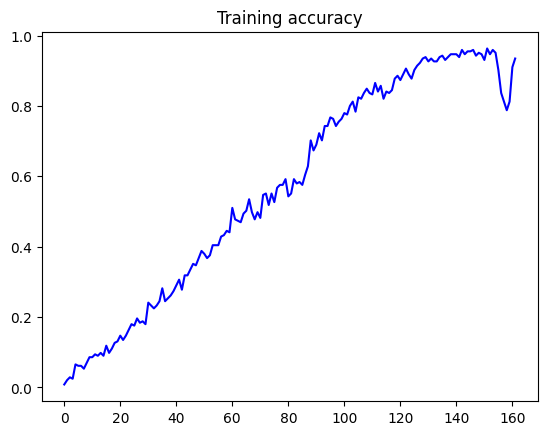

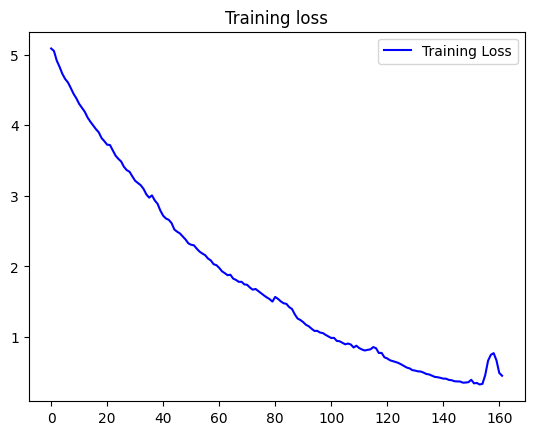

In [173]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training accuracy')

plt.figure()

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.title('Training loss')
plt.legend()

plt.show()

## B. Generate texts


2. "Snow White lived in the forest with..."

In [203]:
seed_text = "Snow White lived in the forest with"
next_words = 10

repetition_penalty_factor = 1 # Adjust this value. Higher = more penalty
generated_words_history = []
history_length = 5

temperature = 0.2

top_k = 0 # Consider only the top K most probable words. Set to 0 to disable.

top_p = 0.9 # Consider words whose cumulative probability exceeds P. Set to 0 to disable.

if top_k > 0 and top_p > 0:
    print("Warning: Both top_k and top_p are active. Prioritizing top_k.")
    top_p = 0 # Deactivate top_p if top_k is set

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

    logits = model.predict(token_list)[0]

    for i, logit_val in enumerate(logits):
        word = tokenizer.index_word.get(i)
        if word in generated_words_history:
            logits[i] -= repetition_penalty_factor * abs(logit_val)

    logits = logits / temperature

    # 3. Apply Top-K or Top-P (Nucleus Sampling)
    if top_k > 0:
        # Sort logits and find the top K
        indices_to_remove = logits.argsort()[:-top_k]
        logits[indices_to_remove] = -float('inf') # Set unwanted logits to a very small number

    elif top_p > 0:
        # Sort logits and calculate cumulative probabilities
        sorted_indices = np.argsort(logits)[::-1] # Sort in descending order
        sorted_logits = logits[sorted_indices]
        cumulative_probs = np.cumsum(np.exp(sorted_logits) / np.sum(np.exp(sorted_logits))) # Calculate cumulative softmax probabilities

        # Find the index where cumulative probability exceeds top_p
        cutoff_index = np.where(cumulative_probs > top_p)[0][0]
        # Remove all tokens after the cutoff
        indices_to_remove = sorted_indices[cutoff_index:]
        logits[indices_to_remove] = -float('inf')

    exp_logits = np.exp(logits - np.max(logits))
    probabilities = exp_logits / np.sum(exp_logits)

    predicted_index = np.random.choice(len(probabilities), p=probabilities)

    output_word = tokenizer.index_word.get(predicted_index)

    if output_word is None:
        output_word = "[UNK]" # Or handle as an error

    seed_text += " " + output_word

    generated_words_history.append(output_word)
    if len(generated_words_history) > history_length:
        generated_words_history.pop(0) # Remove the oldest word

print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Snow White lived in the forest with then alone this magic it in spot grew but her


3. "The queen looked into the mirror and said..."

In [196]:
seed_text = "The queen looked into the mirror and said"
next_words = 10

repetition_penalty_factor = 1.2 # Adjust this value. Higher = more penalty
generated_words_history = []
history_length = 5

temperature = 0.2

top_k = 5 # Consider only the top K most probable words. Set to 0 to disable.

top_p = 0.9 # Consider words whose cumulative probability exceeds P. Set to 0 to disable.

if top_k > 0 and top_p > 0:
    print("Warning: Both top_k and top_p are active. Prioritizing top_k.")
    top_p = 0 # Deactivate top_p if top_k is set

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

    logits = model.predict(token_list)[0]

    for i, logit_val in enumerate(logits):
        word = tokenizer.index_word.get(i)
        if word in generated_words_history:
            logits[i] -= repetition_penalty_factor * abs(logit_val)

    logits = logits / temperature

    # 3. Apply Top-K or Top-P (Nucleus Sampling)
    if top_k > 0:
        # Sort logits and find the top K
        indices_to_remove = logits.argsort()[:-top_k]
        logits[indices_to_remove] = -float('inf') # Set unwanted logits to a very small number

    elif top_p > 0:
        # Sort logits and calculate cumulative probabilities
        sorted_indices = np.argsort(logits)[::-1] # Sort in descending order
        sorted_logits = logits[sorted_indices]
        cumulative_probs = np.cumsum(np.exp(sorted_logits) / np.sum(np.exp(sorted_logits))) # Calculate cumulative softmax probabilities

        # Find the index where cumulative probability exceeds top_p
        cutoff_index = np.where(cumulative_probs > top_p)[0][0]
        # Remove all tokens after the cutoff
        indices_to_remove = sorted_indices[cutoff_index:]
        logits[indices_to_remove] = -float('inf')

    exp_logits = np.exp(logits - np.max(logits))
    probabilities = exp_logits / np.sum(exp_logits)

    predicted_index = np.random.choice(len(probabilities), p=probabilities)

    output_word = tokenizer.index_word.get(predicted_index)

    if output_word is None:
        output_word = "[UNK]" # Or handle as an error

    seed_text += " " + output_word

    generated_words_history.append(output_word)
    if len(generated_words_history) > history_length:
        generated_words_history.pop(0) # Remove the oldest word

print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
The queen looked into the mirror and said he did not return spot one little innocent calling mirror


4. "One day, Snow White found a small cottage and..."

In [194]:
seed_text = "One day, Snow White found a small cottage and"
next_words = 10

repetition_penalty_factor = 1.2 # Adjust this value. Higher = more penalty
generated_words_history = []
history_length = 5

temperature = 0.2

top_k = 5 # Consider only the top K most probable words. Set to 0 to disable.

top_p = 0.9 # Consider words whose cumulative probability exceeds P. Set to 0 to disable.

if top_k > 0 and top_p > 0:
    print("Warning: Both top_k and top_p are active. Prioritizing top_k.")
    top_p = 0 # Deactivate top_p if top_k is set

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

    logits = model.predict(token_list)[0]

    for i, logit_val in enumerate(logits):
        word = tokenizer.index_word.get(i)
        if word in generated_words_history:
            logits[i] -= repetition_penalty_factor * abs(logit_val)

    logits = logits / temperature

    # 3. Apply Top-K or Top-P (Nucleus Sampling)
    if top_k > 0:
        # Sort logits and find the top K
        indices_to_remove = logits.argsort()[:-top_k]
        logits[indices_to_remove] = -float('inf') # Set unwanted logits to a very small number

    elif top_p > 0:
        # Sort logits and calculate cumulative probabilities
        sorted_indices = np.argsort(logits)[::-1] # Sort in descending order
        sorted_logits = logits[sorted_indices]
        cumulative_probs = np.cumsum(np.exp(sorted_logits) / np.sum(np.exp(sorted_logits))) # Calculate cumulative softmax probabilities

        # Find the index where cumulative probability exceeds top_p
        cutoff_index = np.where(cumulative_probs > top_p)[0][0]
        # Remove all tokens after the cutoff
        indices_to_remove = sorted_indices[cutoff_index:]
        logits[indices_to_remove] = -float('inf')

    exp_logits = np.exp(logits - np.max(logits))
    probabilities = exp_logits / np.sum(exp_logits)

    predicted_index = np.random.choice(len(probabilities), p=probabilities)

    output_word = tokenizer.index_word.get(predicted_index)

    if output_word is None:
        output_word = "[UNK]" # Or handle as an error

    seed_text += " " + output_word

    generated_words_history.append(output_word)
    if len(generated_words_history) > history_length:
        generated_words_history.pop(0) # Remove the oldest word

print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
One day, Snow White found a small cottage and the forest began to far ran away off little spot


In [209]:
seed_text = "Snow white is the"
next_words = 10

repetition_penalty_factor = 1.2 # Adjust this value. Higher = more penalty
generated_words_history = []
history_length = 5

temperature = 0.2

top_k = 5 # Consider only the top K most probable words. Set to 0 to disable.

top_p = 0 # Consider words whose cumulative probability exceeds P. Set to 0 to disable.

if top_k > 0 and top_p > 0:
    print("Warning: Both top_k and top_p are active. Prioritizing top_k.")
    top_p = 0 # Deactivate top_p if top_k is set

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

    logits = model.predict(token_list)[0]

    for i, logit_val in enumerate(logits):
        word = tokenizer.index_word.get(i)
        if word in generated_words_history:
            logits[i] -= repetition_penalty_factor * abs(logit_val)

    logits = logits / temperature

    # 3. Apply Top-K or Top-P (Nucleus Sampling)
    if top_k > 0:
        # Sort logits and find the top K
        indices_to_remove = logits.argsort()[:-top_k]
        logits[indices_to_remove] = -float('inf') # Set unwanted logits to a very small number

    elif top_p > 0:
        # Sort logits and calculate cumulative probabilities
        sorted_indices = np.argsort(logits)[::-1] # Sort in descending order
        sorted_logits = logits[sorted_indices]
        cumulative_probs = np.cumsum(np.exp(sorted_logits) / np.sum(np.exp(sorted_logits))) # Calculate cumulative softmax probabilities

        # Find the index where cumulative probability exceeds top_p
        cutoff_index = np.where(cumulative_probs > top_p)[0][0]
        # Remove all tokens after the cutoff
        indices_to_remove = sorted_indices[cutoff_index:]
        logits[indices_to_remove] = -float('inf')

    exp_logits = np.exp(logits - np.max(logits))
    probabilities = exp_logits / np.sum(exp_logits)

    predicted_index = np.random.choice(len(probabilities), p=probabilities)

    output_word = tokenizer.index_word.get(predicted_index)

    if output_word is None:
        output_word = "[UNK]" # Or handle as an error

    seed_text += " " + output_word

    generated_words_history.append(output_word)
    if len(generated_words_history) > history_length:
        generated_words_history.pop(0) # Remove the oldest word

print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Snow white is the loveliest in the land forest cry mirror away spot innocent
